# Color

Por defecto en OpenCV las imágenes en color se cargan en formato BGR: el primer canal es el canal azul (B), el segundo canal es el verde (G) y el tercer canal, el rojo (R).

Para cambiar de espacio de color existe la función `cvtColor` que recibe como primer parámetro la imagen a transformar y, como segundo parámetro, una constante que representa el espacio de color actual de la imagen y el espacio de color de salida de la imagen. La salida de esta función es la imagen transformada al espacio de color elegido.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%matplotlib inline
%matplotlib inline
from matplotlib import pyplot as plt

import numpy as np
import cv2
!pwd
%cd /content


/content
/content


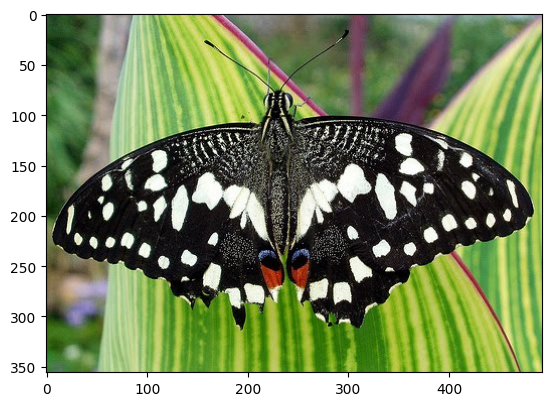

In [4]:
im = cv2.imread('/content/drive/MyDrive/res/butterfly.jpg')

im_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

plt.imshow(im_rgb)
plt.show()

Algunos de los posibles de cambios de espacio color son:

- GRAY: `cv2.COLOR_BGR2GRAY`, `cv2.COLOR_RGB2GRAY`, `COLOR_GRAY2BGR, COLOR_GRAY2RGB`
- XYZ: `cv2.COLOR_BGR2XYZ`, `cv2.COLOR_RBG2XYZ`, `cv2.COLOR_XYZ2RGB`, `cv2.COLOR_XYZ2BGR`,
- YCrCb: `cv2.COLOR_BGR2YCrCb`, `cv2.COLOR_RBG2YCrCb`, `cv2.COLOR_YCrCb2BGR`, `cv2.COLOR_YCrCb2RGB`
- HSV: `cv2.COLOR_BGR2HSV`, `cv2.COLOR_RGB2HSV`, `cv2.COLOR_HSV2BGR`, `cv2.COLOR_HSV2RGB`
- HSL: `cv2.COLOR_BGR2HLS`, `cv2.COLOR_RGB2HLS`, `cv2.COLOR_HLS2BGR`, `cv2.COLOR_HLS2RGB`
- Lab: `cv2.COLOR_BGR2Lab`, `cv2.COLOR_RGB2Lab`, `cv2.COLOR_Lab2BGR`, `cv2.COLOR_Lab2RGB`
- Luv: `cv2.COLOR_BGR2Luv`, `cv2.COLOR_RGB2Luv`, `cv2.COLOR_Luv2BGR`, `cv2.COLOR_Luv2RGB`

## Ejercicios

1) Convierte la imagen de la mariposa de BGR a los espacios de color RGB, HSV y Lab. En cada uno de estos espacios de color:
a) Visualiza cada uno de los canales por separado
b) Comprueba cuáles son los valores mínimos y máximos de cada canal


Analizando los espacios de color...

RGB - Canal R: Mínimo = 0, Máximo = 255
RGB - Canal G: Mínimo = 0, Máximo = 255
RGB - Canal B: Mínimo = 0, Máximo = 255


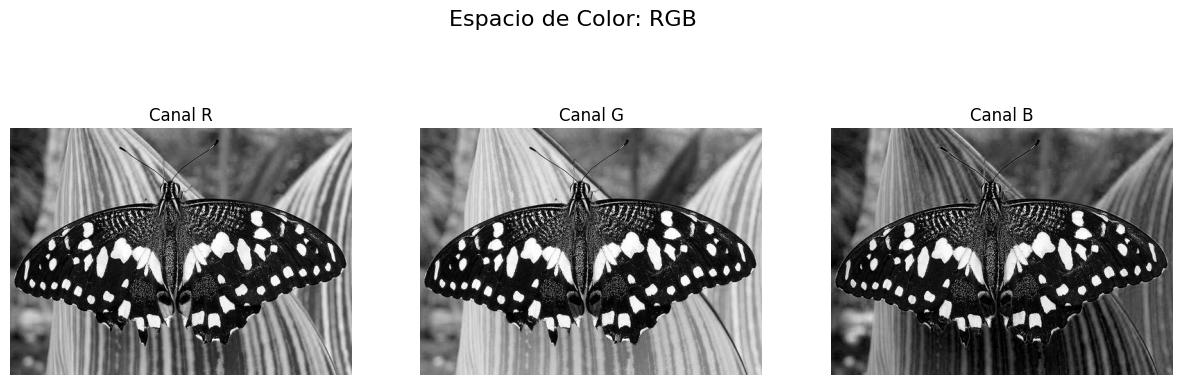

--------------------------------------------------
HSV - Canal H: Mínimo = 0, Máximo = 179
HSV - Canal S: Mínimo = 0, Máximo = 255
HSV - Canal V: Mínimo = 0, Máximo = 255


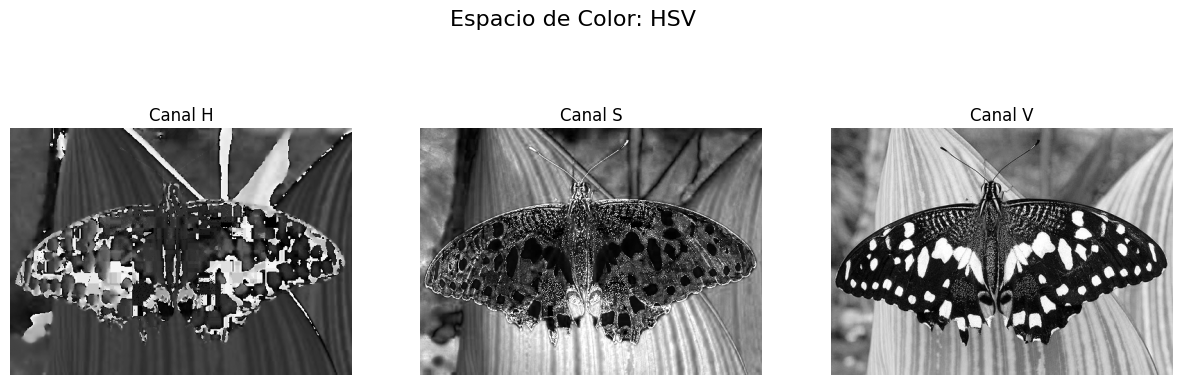

--------------------------------------------------
Lab - Canal L: Mínimo = 0, Máximo = 255
Lab - Canal a: Mínimo = 81, Máximo = 183
Lab - Canal b: Mínimo = 94, Máximo = 197


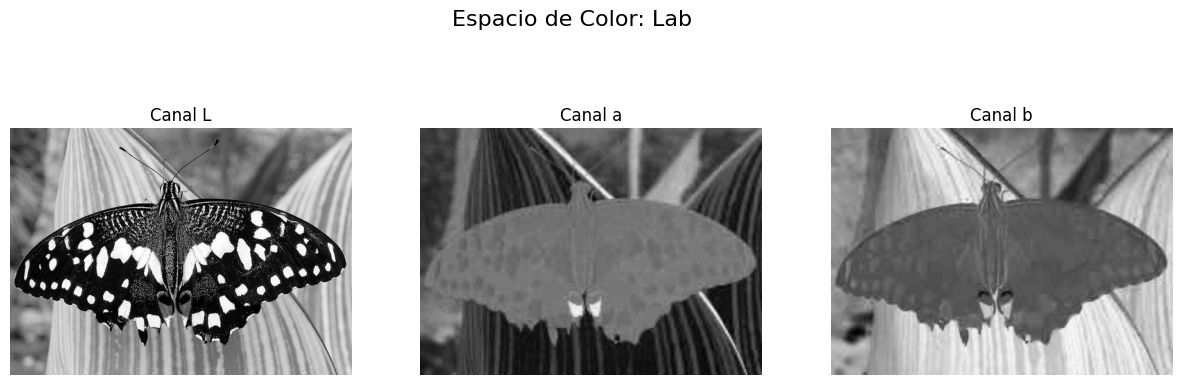

--------------------------------------------------


In [6]:
# Convertir a los diferentes espacios de color
im_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
im_hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
im_lab = cv2.cvtColor(im, cv2.COLOR_BGR2LAB) # Nota: en OpenCV suele ser en mayúsculas

# Función auxiliar para visualizar y calcular min/max
def analizar_espacio_color(imagen, nombre_espacio, nombres_canales):
    # a) Separar los canales
    c1, c2, c3 = cv2.split(imagen)
    canales = [c1, c2, c3]

    # Configurar la visualización
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Espacio de Color: {nombre_espacio}', fontsize=16)

    for i, (canal, nombre) in enumerate(zip(canales, nombres_canales)):
        # Visualizar en escala de grises (así se representan los canales individuales)
        axs[i].imshow(canal, cmap='gray')
        axs[i].set_title(f'Canal {nombre}')
        axs[i].axis('off')

        # b) Comprobar valores mínimos y máximos
        val_min = np.min(canal)
        val_max = np.max(canal)
        print(f"{nombre_espacio} - Canal {nombre}: Mínimo = {val_min}, Máximo = {val_max}")

    plt.show()
    print("-" * 50)

# Ejecutar el análisis para cada espacio
print("Analizando los espacios de color...\n")
analizar_espacio_color(im_rgb, 'RGB', ['R', 'G', 'B'])
analizar_espacio_color(im_hsv, 'HSV', ['H', 'S', 'V'])
analizar_espacio_color(im_lab, 'Lab', ['L', 'a', 'b'])

2) El canal H de HSV toma valores de 0 a 360 (0 a 180 en OpenCV) en el que cada valor respresenta un color. Así, 0 es rojo, 30 es amarillo, 60 es verde, 120 es azul y 150 es morado. En la imagen de la mariposa, encuentra las regiones de la imagen de color morado. *Hints*: usa operadores de comparación.

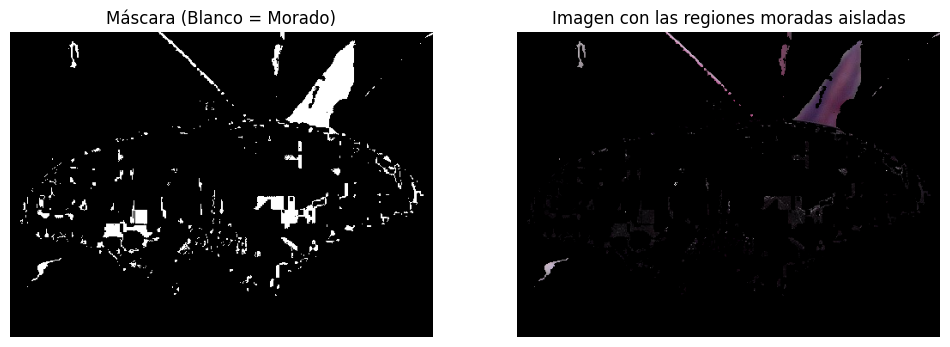

In [7]:
# Extraer los canales de la imagen HSV
H, S, V = cv2.split(im_hsv)

# Definir el rango para el color morado usando operadores de comparación
# Esto crea una matriz booleana (True donde es morado, False donde no)
mascara_morada = (H > 135) & (H < 165)

# Para visualizar el resultado, extraemos solo los píxeles morados de la imagen RGB original
resultado_morado = np.zeros_like(im_rgb) # Matriz negra del mismo tamaño
resultado_morado[mascara_morada] = im_rgb[mascara_morada] # Copiamos solo los píxeles que cumplen la condición

# Visualizar la máscara y el resultado final
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(mascara_morada, cmap='gray')
axs[0].set_title('Máscara (Blanco = Morado)')
axs[0].axis('off')

axs[1].imshow(resultado_morado)
axs[1].set_title('Imagen con las regiones moradas aisladas')
axs[1].axis('off')

plt.show()

3) Determina cuál es el espacio de color (RGB, Lab o HSV) y el canal o canales que aportan más información en las siguientes imágenes:

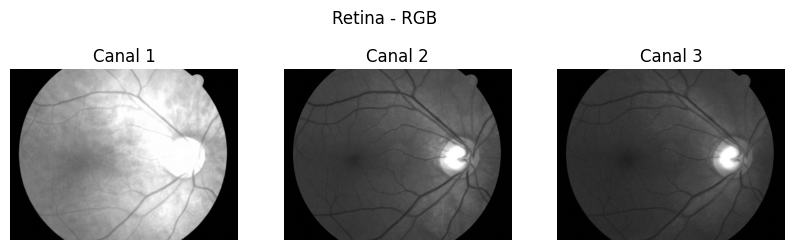

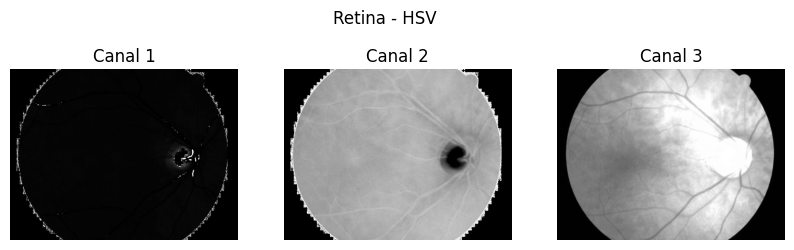

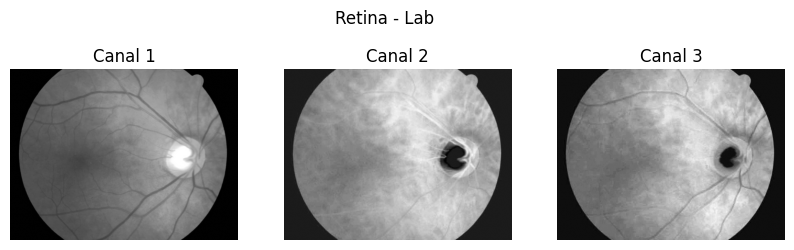

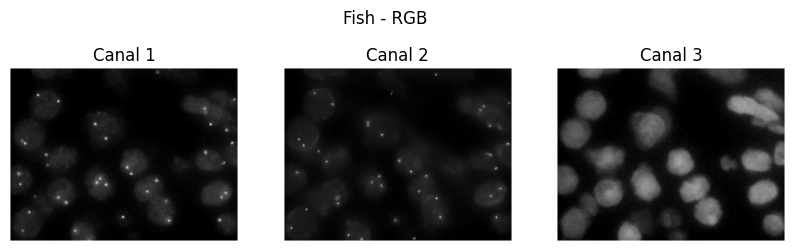

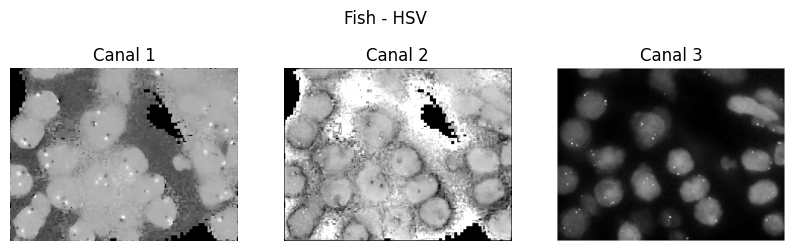

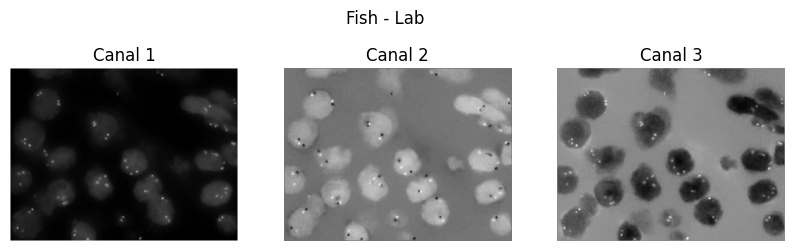

In [8]:
im1 = cv2.imread('/content/drive/MyDrive/res/retino.jpg') # Detectar vasos
im2 = cv2.imread('/content/drive/MyDrive/res/fish.jpg') # Detectar células y marcadores

# Escribe aquí tu código

def mostrar_canales(img, titulo):
    c1, c2, c3 = cv2.split(img)

    plt.figure(figsize=(10,3))
    for i, canal in enumerate([c1, c2, c3]):
        plt.subplot(1,3,i+1)
        plt.imshow(canal, cmap='gray')
        plt.title(f'Canal {i+1}')
        plt.axis('off')
    plt.suptitle(titulo)
    plt.show()


# Convertir imágenes
im1_rgb = cv2.cvtColor(im1, cv2.COLOR_BGR2RGB)
im1_hsv = cv2.cvtColor(im1, cv2.COLOR_BGR2HSV)
im1_lab = cv2.cvtColor(im1, cv2.COLOR_BGR2LAB)

im2_rgb = cv2.cvtColor(im2, cv2.COLOR_BGR2RGB)
im2_hsv = cv2.cvtColor(im2, cv2.COLOR_BGR2HSV)
im2_lab = cv2.cvtColor(im2, cv2.COLOR_BGR2LAB)

# Mostrar canales retina
mostrar_canales(im1_rgb, "Retina - RGB")
mostrar_canales(im1_hsv, "Retina - HSV")
mostrar_canales(im1_lab, "Retina - Lab")

# Mostrar canales fish
mostrar_canales(im2_rgb, "Fish - RGB")
mostrar_canales(im2_hsv, "Fish - HSV")
mostrar_canales(im2_lab, "Fish - Lab")
